# Object-oriented programming

We now perform the exact same task but with OOP. We set up a very simple class that stores the parameters of our heat diffusion problem, provides a solving function and a simple plotting function. We will go through the same sequence of steps as in the other notebook.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Coding the class

<div style="background-color:#AABAB2; color: black; vertical-align: middle; padding:15px; margin: 10px; border-radius: 10px">
<b>Task 2.1:</b> 
Go through the OOP material in the book and then complete the missing parts in the code below
</div>

<div style="background-color:#facb8e; color: black; vertical-align: middle; padding:15px; margin: 10px; border-radius: 10px"> <p>

$\text{Tips:}$

- The constructor `__init__` will be run every time an instance of the class is created. Note that it takes parameters!
- Note carefully which parameters are stored inside the class (preceeded by `self.`). They can be used by any function in the class. Remember to always include `self.`, otherwise the variable will not be recognized!
</p>
</div>

In [2]:
class Diffusion:
    def __init__(self, L, dx, dt):
        self.L = L
        self.dx = dx
        self.dt = dt
        self.x = np.arange(0,self.L+self.dx,self.dx)

        # some standard values
        self.kappa = 0
        self.init_temp = 0
        self.bc_left = 0
        self.bc_right = 0
        
    def set_pde_params(self, kappa):
        self.kappa = kappa
        assert self.kappa*self.dt/self.dx/self.dx<=0.5, 'Stability condition not satisfied'

    def set_bcs(self, init, left, right):        
        self.init_temp = init
        self.bc_left = left
        self.bc_right = right

    def plot_steps(self,steps):
        plt.figure()
        plt.xlabel('Position')
        plt.ylabel('Temperature')
        for step in steps:
            plt.plot(self.x, self.T[step,:], label='step '+str(step))
        plt.legend()
        plt.show()

    def _apply_bcs(self, n):
        self.T[n+1,0] = self.bc_left
        self.T[n+1,-1] = self.T[n,-1] + 2*self.kappa*self.dt/self.dx/self.dx * (self.T[n,-2] - self.T[n,-1] + self.bc_right*self.dx)

    def solve(self, n_steps):
        # solution vectors
        nx = len(self.x)
        self.T = np.zeros((n_steps,nx))
    
        # temperature field at t=0
        self.T[0,:] = self.init_temp
    
        # loop through time
        for n in range(n_steps-1):
            # solution in the interior
            for m in range(1,nx-1):
                self.T[n+1,m] = self.T[n,m] + self.kappa*self.dt/self.dx/self.dx * (self.T[n,m+1]-2*self.T[n,m]+self.T[n,m-1]) 
            
            # solution at the boundaries
            self._apply_bcs(n)

### Running the code
Now use your new class in the block below to get results for the same case we treated in Part 1.

<div style="background-color:#AABAB2; color: black; vertical-align: middle; padding:15px; margin: 10px; border-radius: 10px">
<b>Task 2.2:</b> 
Run the code for the following case:
    
- **Domain and discretization**: $L=1$, $\Delta x = 0.1$, $\Delta t = 0.001$

- **PDE parameters**: $\kappa=1$

- **Initial and boundary conditions**: $T_\mathrm{init}=25$, $T_\mathrm{left}=100$, $h_\mathrm{right}=0$

- **Solver parameters**: Run for 1000 time steps

After running, plot your solution over $x$ at time steps 0, 10, 100 and at the last step together on the same plot. 
</div>

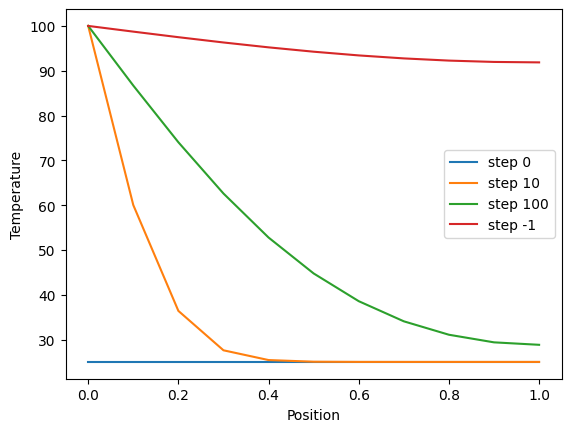

In [3]:
model = Diffusion(L=1,dx=0.1,dt=0.001)
model.set_pde_params(kappa=1)
model.set_bcs(init=25,left=100,right=0)

model.solve(n_steps=1000)

model.plot_steps([0,10,100,-1])

See how much more natural it felt this time? Our class organizes parameters in a way that makes sense and provides interfaces that promote **gradual model building** and improved user experience. 

<div style="background-color:#AABAB2; color: black; vertical-align: middle; padding:15px; margin: 10px; border-radius: 10px">
<b>Task 2.3:</b> 
    
In the block below, use the same `model` object from the previous block and run it again for $\kappa=5$. Do not reinstantiate `model` and do not change any other parameters.
</div>

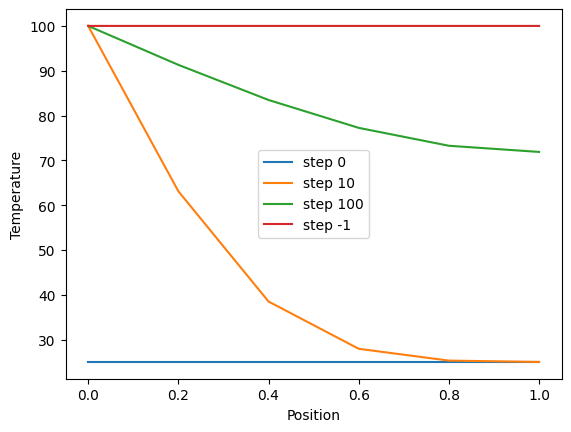

In [4]:
model.set_pde_params(kappa=5)
model.solve(n_steps=1000)
model.plot_steps([0,10,100,-1])

The code now looks much cleaner than before! Aside from the number of time steps, we did not have to repeat any parameters other than the one we wanted to change.

## Extending the solver

Now for our final trick! Let us extend the solver as we did before, to consider a temperature boundary condition also on the right end of the bar. But not instead of coding everything again from scratch we will use **inheritance**. We will create a new `MyDiffusion` class that inherits from the original, and because everything is inherited **we only need to code what is different**.

<div style="background-color:#AABAB2; color: black; vertical-align: middle; padding:15px; margin: 10px; border-radius: 10px">
<b>Task 2.4:</b> 
Complete the missing parts in the code below
</div>

In [5]:
class MyDiffusion (Diffusion):
    def _apply_bcs(self, n):
        self.T[n+1,0] = self.bc_left
        self.T[n+1,-1] = self.bc_right

Pretty cool, right? It could be made even shorter by having dedicated functions for the BC on the left and on the right in the original class, but conceptually that would be a bit awkward. When using OOP there is always a balance to be found in how specialized individual classes and functions are. The primary goal is to make the code easier to read and extend, not to bring the number of code lines to an absolute minimum.

<div style="background-color:#AABAB2; color: black; vertical-align: middle; padding:15px; margin: 10px; border-radius: 10px">
<b>Task 2.5:</b> 

Now to wrap it up use your new class to run the example again with $\kappa=1$ and $T_\mathrm{right}=50$

</div>

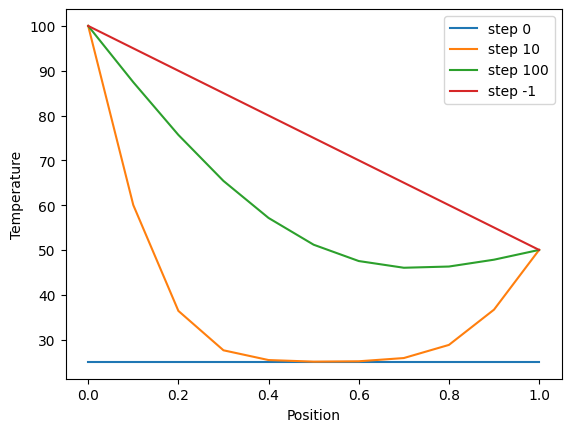

In [6]:
new_model = MyDiffusion(L=1,dx=0.1,dt=0.001)
new_model.set_pde_params(kappa=1)
new_model.set_bcs(init=25,left=100,right=50)

new_model.solve(n_steps=1000)

new_model.plot_steps([0,10,100,-1])

> By Iuri Rocha and Marcel Zijlema, Delft University of Technology. CC BY 4.0, more info [on the Credits page of Workbook](https://mude.citg.tudelft.nl/workbook-2025/credits.html).